# **🚗 US Traffic Accidents : Data Report**
This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The dataset currently contains **approximately 7.7 million accident records**.

## **Dataset Overview**
| Column Name | Description | | Column Name | Description |
| :--- | :--- | :--- | :--- | :--- |
| **ID** | This is a unique identifier of the accident record. | | **Pressure(in)** | Shows the air pressure (in inches). |
| **Source** | Source of raw accident data. | | **Visibility(mi)** | Shows visibility (in miles). |
| **Severity** | Shows the severity of the accident, a number between 1 and 4. | | **Wind_Direction** | Shows wind direction. |
| **Start_Time** | Shows start time of the accident in local time zone. | | **Wind_Speed(mph)** | Shows wind speed (in miles per hour). |
| **End_Time** | Shows end time of the accident in local time zone. | | **Precipitation(in)** | Shows precipitation amount in inches, if there is any. |
| **Start_Lat** | Shows latitude in GPS coordinate of the start point. | | **Weather_Condition** | Shows the weather condition (rain, snow, etc.). |
| **Start_Lng** | Shows longitude in GPS coordinate of the start point. | | **Amenity** | POI annotation: presence of amenity nearby. |
| **End_Lat** | Shows latitude in GPS coordinate of the end point. | | **Bump** | POI annotation: presence of speed bump/hump nearby. |
| **End_Lng** | Shows longitude in GPS coordinate of the end point. | | **Crossing** | POI annotation: presence of crossing nearby. |
| **Distance(mi)** | The length of the road extent affected in miles. | | **Give_Way** | POI annotation: presence of give_way nearby. |
| **Description** | Shows a human provided description of the accident. | | **Junction** | POI annotation: presence of junction nearby. |
| **Street** | Shows the street name in address field. | | **No_Exit** | POI annotation: presence of no_exit nearby. |
| **City** | Shows the city in address field. | | **Railway** | POI annotation: presence of railway nearby. |
| **County** | Shows the county in address field. | | **Roundabout** | POI annotation: presence of roundabout nearby. |
| **State** | Shows the state in address field. | | **Station** | POI annotation: presence of station nearby. |
| **Zipcode** | Shows the zipcode in address field. | | **Stop** | POI annotation: presence of stop nearby. |
| **Country** | Shows the country in address field. | | **Traffic_Calming** | POI annotation: presence of traffic_calming nearby. |
| **Timezone** | Shows timezone based on the location of the accident. | | **Traffic_Signal** | POI annotation: presence of traffic_signal nearby. |
| **Airport_Code** | Denotes the closest airport-based weather station. | | **Turning_Loop** | POI annotation: presence of turning_loop nearby. |
| **Weather_Timestamp** | Time-stamp of weather observation record. | | **Sunrise_Sunset** | Shows the period of day based on sunrise/sunset. |
| **Temperature(F)** | Shows the temperature (in Fahrenheit). | | **Civil_Twilight** | Shows the period of day based on civil twilight. |
| **Wind_Chill(F)** | Shows the wind chill (in Fahrenheit). | | **Nautical_Twilight** | Shows the period of day based on nautical twilight. |
| **Humidity(%)** | Shows the humidity (in percentage). | | **Astronomical_Twilight** | Shows the period of day based on astronomical twilight. |

### **🎯 Notebook Goal & Scope**

The primary objective of this notebook is to conduct a thorough Exploratory Data Analysis (EDA) on the dataset, which spans from February 2016 to March 2023. By analyzing over 7.7 million records, we aim to uncover:
*   **Temporal Patterns:** How accident frequencies change across different hours of the day, days of the week, and seasons.
*   **Spatial Hotspots:** Identifying the most dangerous cities, streets, and states.
*   **Environmental Triggers:** The impact of weather conditions, visibility, precipitation, and temperature on traffic accidents.

### **🤖 Machine Learning Applications**

#### 1. Classification (Predicting Accident Severity)
*   **Target Variable:** `Severity` (values ranging from 1 to 4, indicating traffic impact).
*   **Goal:** Build a multi-class classification model (e.g., Random Forest, XGBoost, or LightGBM) to predict how severe a traffic delay will be based on situational factors.
*   **Features to use:** `Temperature(F)`, `Humidity(%)`, `Visibility(mi)`, `Weather_Condition`, `Timezone`, and POI features like `Junction`, `Traffic_Signal`, or `Crossing`.

#### 2. Regression (Predicting Delay Duration or Distance Affected)
*   **Target Variable:** Total impact duration ($\text{End\_Time} - \text{Start\_Time}$) or `Distance(mi)`.
*   **Goal:** Train regression models to estimate the physical length of the road affected or the expected clearance time, helping emergency services optimize resource allocation.

#### 3. Spatial-Temporal Risk Forecasting
*   **Goal:** By grouping the coordinates (`Start_Lat`, `Start_Lng`) and timestamps, you can engineer a target representing "Accident Probability" for a given grid section at a specific hour, allowing for predictive policing and preemptive routing solutions.

#### ⚠️ Key Challenges to Consider for ML:
*   **Imbalanced Classes:** Minor accidents are far more frequent than catastrophic ones; techniques like SMOTE or adjusting class weights will be crucial.
*   **Missing Data:** Columns like `Wind_Chill(F)` or `Precipitation(in)` have structural null values that require strategic imputation.
*   **High Cardinality:** Categorical variables like `Street` and `Zipcode` have hundreds of thousands of unique entries, requiring advanced encoding techniques (like Target Encoding) or aggregation before modeling.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

%pip install contextily
%pip install ipyleaflet

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import contextily as ctx
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [3]:
data.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [4]:
# Drop the useless columns
columns_to_drop = [
    'ID', 'Description',               # Arbitrary text/identifiers
    'End_Lat', 'End_Lng',             # Missing ~44% of data (redundant with Start)
    'Wind_Chill(F)', 'Precipitation(in)' # Missing massive chunks of data
]
data.drop(columns=columns_to_drop, inplace=True, errors='ignore')


# imputing numerical columns for extra data
# Fill with median (Robust against skewed weather outliers)
median_cols = ['Wind_Speed(mph)', 'Visibility(mi)', 'Pressure(in)']
for col in median_cols:
    data[col] = data[col].fillna(data[col].median())

# Fill with mean (Good for normally distributed weather data)
mean_cols = ['Temperature(F)', 'Humidity(%)']
for col in mean_cols:
    data[col] = data[col].fillna(data[col].mean())


# imputing categorical columns
# Fill with mode
mode_cols = [
    'Weather_Condition', 'Wind_Direction', 'Timezone', 'Airport_Code',
    'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'
]
for col in mode_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Handle specific location string columns with a generic placeholder
location_cols = ['Street', 'City', 'Zipcode']
for col in location_cols:
    data[col] = data[col].fillna('Unknown')

In [5]:
data.isnull().sum()

Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
Distance(mi)                  0
Street                        0
City                          0
County                        0
State                         0
Zipcode                       0
Country                       0
Timezone                      0
Airport_Code                  0
Weather_Timestamp        120228
Temperature(F)                0
Humidity(%)                   0
Pressure(in)                  0
Visibility(mi)                0
Wind_Direction                0
Wind_Speed(mph)               0
Weather_Condition             0
Amenity                       0
Bump                          0
Crossing                      0
Give_Way                      0
Junction                      0
No_Exit                       0
Railway                       0
Roundabout                    0
Station 

In [6]:
data.head(10)

,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,County,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,I-70 E,Dayton,Montgomery,...,False,False,False,False,False,False,Night,Night,Night,Night
1,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Brice Rd,Reynoldsburg,Franklin,...,False,False,False,False,False,False,Night,Night,Night,Day
2,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,State Route 32,Williamsburg,Clermont,...,False,False,False,False,True,False,Night,Night,Day,Day
3,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,I-75 S,Dayton,Montgomery,...,False,False,False,False,False,False,Night,Day,Day,Day
4,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Miamisburg Centerville Rd,Dayton,Montgomery,...,False,False,False,False,True,False,Day,Day,Day,Day
5,Source2,3,2016-02-08 07:44:26,2016-02-08 08:14:26,40.100590,-82.925194,0.01,Westerville Rd,Westerville,Franklin,...,False,False,False,False,False,False,Day,Day,Day,Day
6,Source2,2,2016-02-08 07:59:35,2016-02-08 08:29:35,39.758274,-84.230507,0.00,N Woodward Ave,Dayton,Montgomery,...,False,False,False,False,False,False,Day,Day,Day,Day
7,Source2,3,2016-02-08 07:59:58,2016-02-08 08:29:58,39.770382,-84.194901,0.01,N Main St,Dayton,Montgomery,...,False,False,False,False,False,False,Day,Day,Day,Day
8,Source2,2,2016-02-08 08:00:40,2016-02-08 08:30:40,39.778061,-84.172005,0.00,Notre Dame Ave,Dayton,Montgomery,...,False,False,False,False,False,False,Day,Day,Day,Day
9,Source2,3,2016-02-08 08:10:04,2016-02-08 08:40:04,40.100590,-82.925194,0.01,Westerville Rd,Westerville,Franklin,...,False,False,False,False,False,False,Day,Day,Day,Day


# **Dataset Exploration and Exploratory Data Analysis (EDA)**

* Temporal analysis of accident frequency across different scales: hour of day, day of week, and month to identify peak rush hours and seasonal patterns
* Correlation analysis between accident severity (the target variable) and continuous weather variables like temperature, humidity, visibility, pressure, and wind speed
* Spatial distribution mapping of accident severity across different states and counties to find regional risk hotspots
* Frequency analysis of road infrastructure POI flags (junctions, crossings, traffic signals, stop signs) to see which physical features correlate most with higher severity levels
* Comparative analysis of daylight versus night conditions (using sunrise/sunset and twilight columns) on the distribution of accident severity
* Missing value pattern analysis to check if missing data in weather stations correlates with specific regions or times
* Cardinality and frequency checks on categorical variables like weather conditions, wind directions, and cities to plan grouping or encoding strategies for the ML models
* Imbalance ratio calculation for the severity target classes to determine how heavily skewed the data is toward specific severity levels
* Pivot table analysis of weather conditions versus road POIs to observe if specific combinations (e.g., rain + junction) disproportionately lead to severe accidents

/tmp/ipykernel_16/1246987051.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Hour', palette='viridis')


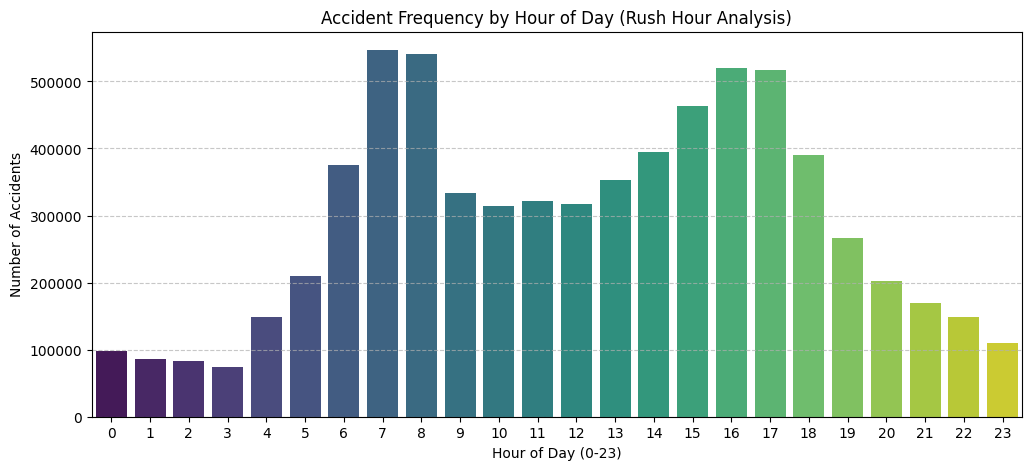

/tmp/ipykernel_16/1246987051.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Day_of_Week', order=days_order, palette='viridis')


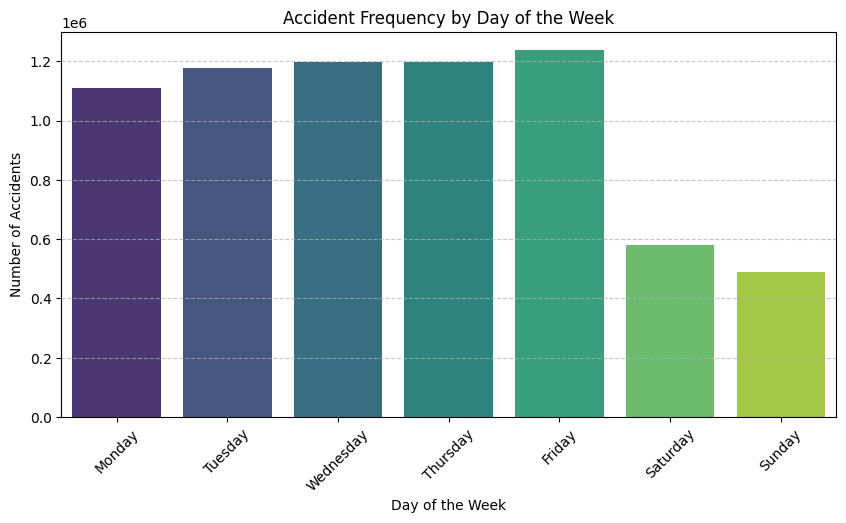

/tmp/ipykernel_16/1246987051.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Month', order=months_order, palette='magma')


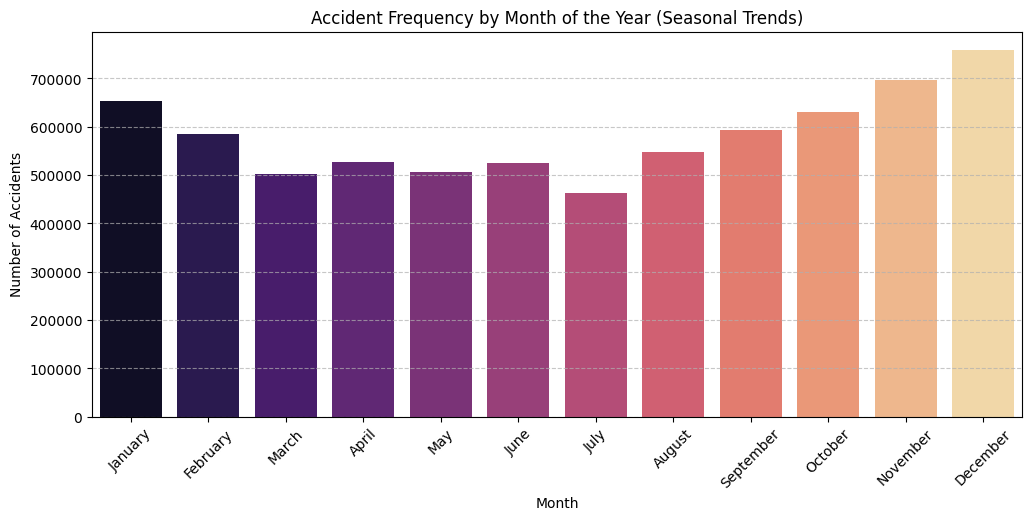

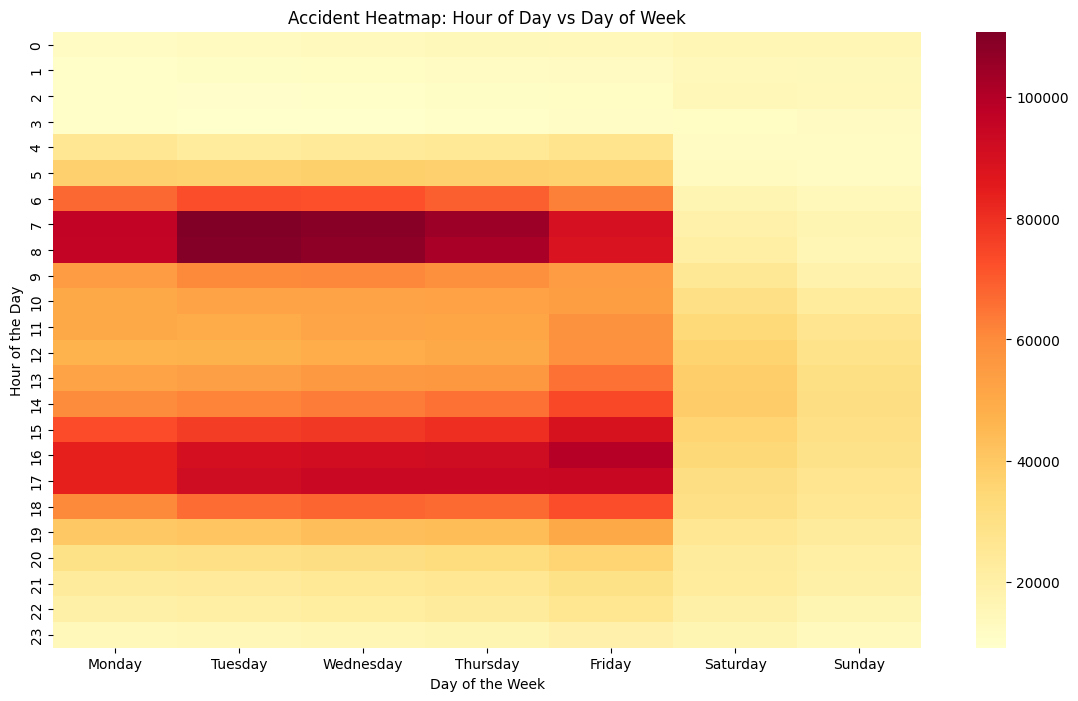

In [7]:
# Convert Start_Time to datetime format (coerce errors to handle irregular formats)
data['Start_Time'] = pd.to_datetime(data['Start_Time'], errors='coerce')

# Drop any rows where Start_Time is null after conversion
data = data.dropna(subset=['Start_Time'])

# Extract temporal components
data['Hour'] = data['Start_Time'].dt.hour
data['Day_of_Week'] = data['Start_Time'].dt.day_name()
data['Month'] = data['Start_Time'].dt.month_name()
data['Year'] = data['Start_Time'].dt.year

# Define chronological orders for cleaner plotting
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']


# Hourly Accident Frequency

plt.figure(figsize=(12, 5))
sns.countplot(data=data, x='Hour', palette='viridis')
plt.title('Accident Frequency by Hour of Day (Rush Hour Analysis)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Weekly Accident Frequency

plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='Day_of_Week', order=days_order, palette='viridis')
plt.title('Accident Frequency by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Monthly Accident Frequency

plt.figure(figsize=(12, 5))
sns.countplot(data=data, x='Month', order=months_order, palette='magma')
plt.title('Accident Frequency by Month of the Year (Seasonal Trends)')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Hour Vs Weekday Heatmap

# Create a pivot table counting accidents for Hour vs Day of Week
heatmap_data = data.groupby(['Day_of_Week', 'Hour']).size().unstack(level=0)
# Reorder columns chronologically
heatmap_data = heatmap_data[days_order]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt="d")
plt.title('Accident Heatmap: Hour of Day vs Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.show()

* Most accidents happen around morning 7-8 AM and 3-5 PM during the afternoon
* Accidents mostly occur in the weekdays and fall very low during the weekends due to the reduced traffic on roads
* The trends of accidents fall from January and then rises again from July onwards, could be due to the changing weather conditions
* Accident heatmaps conclude that the most accidents occur on Tuesday-Wednesday during morning hours

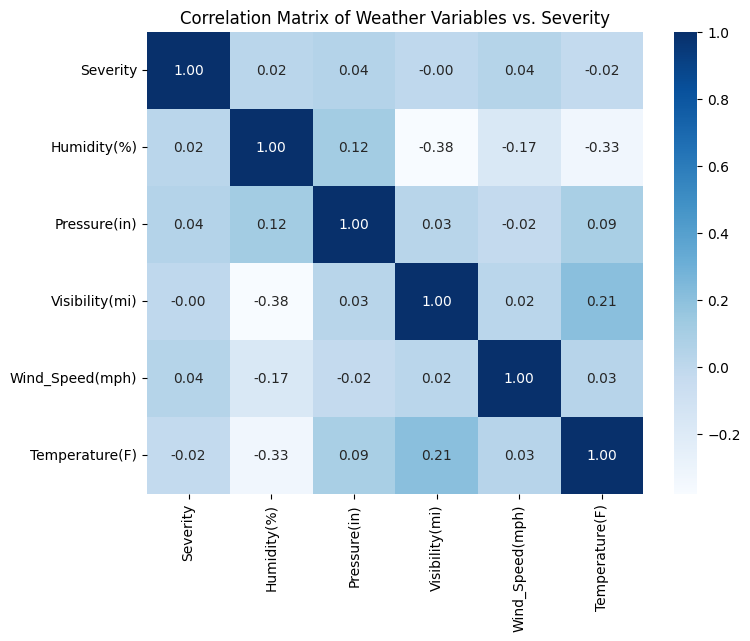

In [8]:
corr_vars = ['Severity', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Temperature(F)']
corr_data = data[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, cmap='Blues', annot=True, fmt=".2f")
plt.title('Correlation Matrix of Weather Variables vs. Severity')
plt.show()

* None of the individual weather variables have a strong direct linear correlation with accident severity, as all correlation coefficients with Severity are extremely close to zero (ranging from -0.02 to 0.04).
* Humidity has a moderate negative correlation with visibility (-0.38), meaning that as humidity increases, road visibility tends to decrease.
* Humidity also has a moderate negative correlation with temperature (-0.33), indicating that higher temperatures generally align with lower relative humidity in this dataset.
* Temperature and visibility share a weak positive correlation (0.21), suggesting that warmer temperatures slightly associate with clearer visibility.
* Because linear correlations with severity are so weak, a simple linear model will likely struggle; non-linear machine learning algorithms (like Random Forest or XGBoost) will be necessary to capture complex interactions between these weather factors and accident severity.

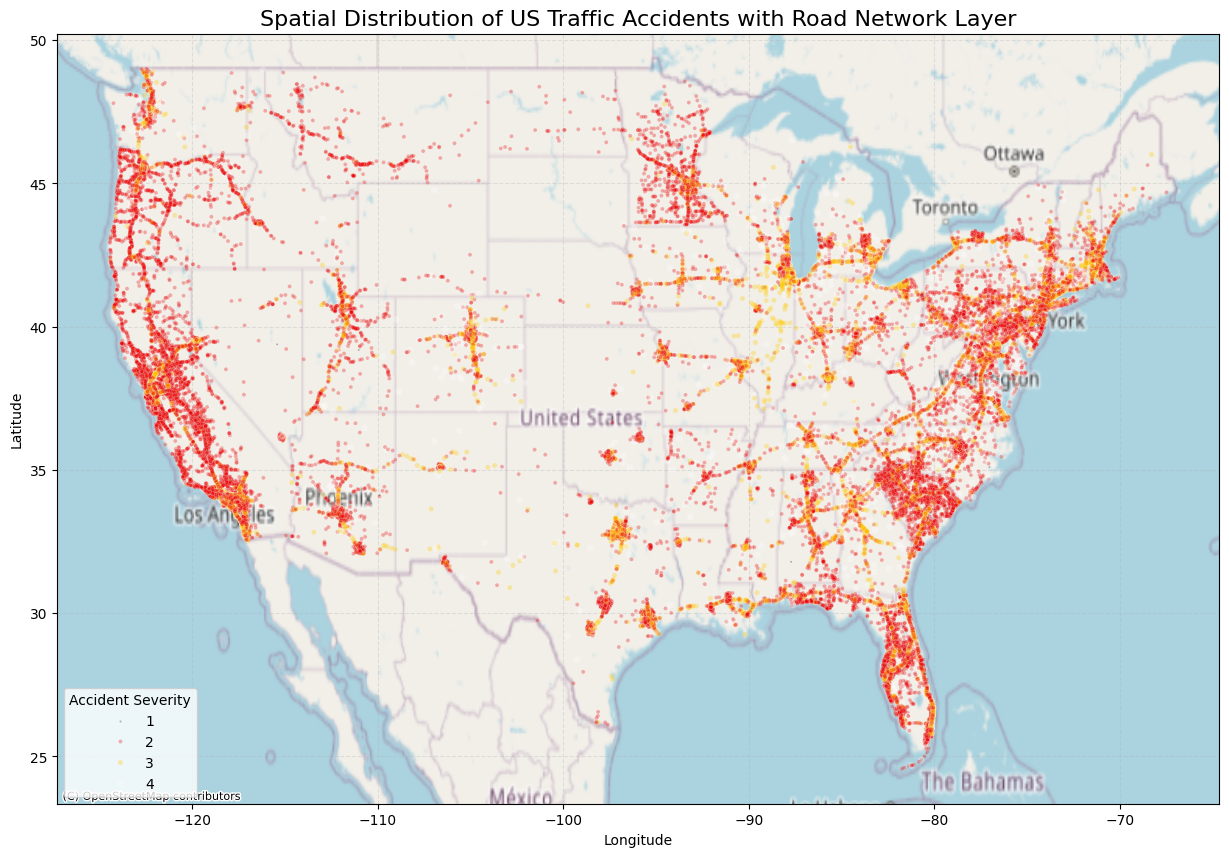

In [9]:
data_sample = data.sample(n=100000, random_state=42)

# Filter out coordinates outside of the contiguous United States
data_contiguous = data_sample[
    (data_sample['Start_Lat'] > 24) & (data_sample['Start_Lat'] < 50) &
    (data_sample['Start_Lng'] > -125) & (data_sample['Start_Lng'] < -66)
]

fig, ax = plt.subplots(figsize=(15, 10))

# Plot the scatter points (set zorder to ensure they render above the map)
sns.scatterplot(
    data=data_contiguous, 
    x='Start_Lng', 
    y='Start_Lat', 
    hue='Severity', 
    palette='hot', 
    alpha=0.3,       # High transparency helps background roads show through
    size='Severity', 
    sizes=(2, 20),
    ax=ax,
    zorder=2         # Force scatter plot to lay on top of the basemap
)

# OpenStreetMap.Mapnik serves a classic map style showcasing major roads and highways
ctx.add_basemap(
    ax, 
    crs='EPSG:4326',                           # Specify WGS84 projection for lat/lon coordinates
    source=ctx.providers.OpenStreetMap.Mapnik, # Choose tile source with clear road lines
    zorder=1                                   # Force map to render underneath the points
)

plt.title('Spatial Distribution of US Traffic Accidents with Road Network Layer', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Accident Severity', loc='lower left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

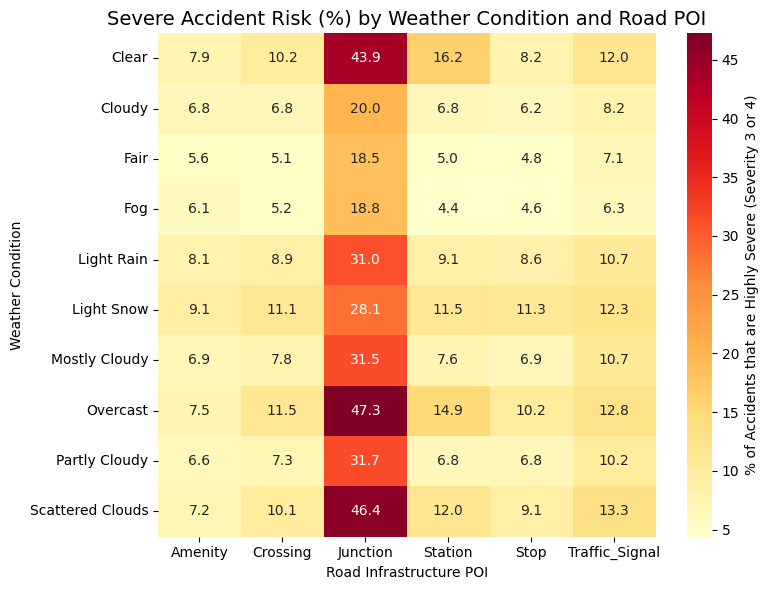

In [10]:
# Select the most common road POI columns to keep the analysis focused
poi_cols = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Amenity']

# Identify the top 10 most frequent weather conditions to avoid a massive, sparse matrix
top_weather = data['Weather_Condition'].value_counts().head(10).index

# Filter the dataframe to only include these top weather conditions
data_filtered = data[data['Weather_Condition'].isin(top_weather)].copy()

# Create a binary column: 1 if accident is highly severe (3 or 4), else 0
data_filtered['Is_Severe'] = data_filtered['Severity'].isin([3, 4]).astype(int)

# Melt the boolean POI columns into a long format
melted_data = data_filtered.melt(
    id_vars=['Weather_Condition', 'Is_Severe'], 
    value_vars=poi_cols, 
    var_name='POI_Type', 
    value_name='Present'
)

# Keep only the rows where the POI physical feature was actually present (True)
melted_data = melted_data[melted_data['Present'] == True]

# Calculate the percentage of severe accidents (mean of our binary 'Is_Severe' column)
pivot_table = melted_data.pivot_table(
    index='Weather_Condition', 
    columns='POI_Type', 
    values='Is_Severe', 
    aggfunc='mean'
)

# Multiply by 100 to convert proportions to percentages (%)
pivot_table_pct = pivot_table * 100

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_table_pct, 
    cmap='YlOrRd', 
    annot=True, 
    fmt=".1f", 
    cbar_kws={'label': '% of Accidents that are Highly Severe (Severity 3 or 4)'}
)

plt.title('Severe Accident Risk (%) by Weather Condition and Road POI', fontsize=14)
plt.xlabel('Road Infrastructure POI')
plt.ylabel('Weather Condition')
plt.tight_layout()

plt.show()

Most severe accidents occur on the junctions regardless of the weather conditions. Highest rate of accidents occur in normal weather conditions with scattered clouds or an overcast

# **Machine Learning Models and Computations**

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score
from lightgbm import LGBMClassifier

# 1. Feature engineering (including coordinates, distance, and time)

# Ensure Start_Time is datetime and extract features
data['Start_Time'] = pd.to_datetime(data['Start_Time'], errors='coerce')
data['Hour'] = data['Start_Time'].dt.hour
data['Day_of_Week'] = data['Start_Time'].dt.dayofweek

# Categorical features
cat_cols = ['Weather_Condition', 'Timezone']

# Numerical features (added Start_Lat, Start_Lng, and Distance)
num_cols = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 
    'Hour', 'Day_of_Week', 'Start_Lat', 'Start_Lng', 'Distance(mi)'
]

# Boolean road POIs
poi_cols = ['Junction', 'Traffic_Signal', 'Crossing']

# Define feature matrix (X) and target array (y)
features = cat_cols + num_cols + poi_cols
X = data[features].copy()

# Convert boolean columns to 0 and 1
for col in poi_cols:
    X[col] = X[col].astype(int)

# Shift Severity from 1-4 to 0-3
y = data['Severity'].astype(int) - 1


# 2. Dynamic sampling and stratified split

# Sample down to 200,000 rows if the dataset is massive to keep training fast
if len(X) > 200000:
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=200000, stratify=y, random_state=42)
else:
    X_sample, y_sample = X, y

# Split into 80% training and 20% validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.20, stratify=y_sample, random_state=42
)


# 3. Preprocessing pipeline (with feature names preserved)

# Standardize numerical columns and one-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

# This line forces the preprocessor to output a pandas DataFrame instead of a NumPy array.
# It completely resolves the feature name warning.
preprocessor.set_output(transform="pandas")

# Transform train and test datasets
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


# 4. Train LightGBM (without aggressive class balancing)

# We remove class_weight='balanced' so the model optimizes for actual overall accuracy.
model = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    num_leaves=63,         # Increased capacity to map coordinate patterns
    random_state=42,
    n_jobs=-1
)

print(f"Training LightGBM model on {len(X_train)} samples...")
model.fit(X_train_preprocessed, y_train)
print("Model training complete!")


# 5. Evaluation

# Generate predictions on the preprocessed test set
y_pred = model.predict(X_test_preprocessed)

# Shift targets and predictions back to original 1-4 scale
y_test_original = y_test + 1
y_pred_original = y_pred + 1

# Display metrics
print("\n" + "="*50)
print(f"Overall Accuracy Score: {accuracy_score(y_test_original, y_pred_original):.4f}")
print("="*50)
print("\nClassification Report:")
print(classification_report(y_test_original, y_pred_original, zero_division=0))

Training LightGBM model on 160000 samples...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1268
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 61
[LightGBM] [Info] Start training from score -4.641445
[LightGBM] [Info] Start training from score -0.251141
[LightGBM] [Info] Start training from score -1.682009
[LightGBM] [Info] Start training from score -3.632735
Model training complete!

Overall Accuracy Score: 0.8293

Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.04      0.08       386
           2       0.85      0.96      0.90     31116
           3       0.71      0.45      0.55      7440
       

### **Key Takeaways & Lessons**
* When a dataset is highly unbalanced (like this, where roughly 78% of the records are Class 2), forcing a "balanced" distribution tells the model to treat the rare classes (like Class 1 and Class 4) as if they are hundreds of times more important than they actually are. This causes the model to over-predict the rare classes, creating massive amounts of false alarms (very low precision) and dragging down overall accuracy. Removing this setting lets the model optimize for predicting actual patterns correctly, reflecting real-world class distributions
* Weather conditions alone are highly weak predictors of how long a road block will last. By introducing geographic coordinates and the distance impacted, the model can now differentiate between minor local street fender-benders and major interstate/highway collisions, which naturally result in longer, more severe traffic delays

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Spatial-temporal feature engineering

# Ensure Start_Time is datetime and extract temporal components
data['Start_Time'] = pd.to_datetime(data['Start_Time'], errors='coerce')
data['Hour'] = data['Start_Time'].dt.hour
data['Day_of_Week'] = data['Start_Time'].dt.dayofweek

# Round coordinates to 2 decimal places to create ~1.1km grid cells
data['Grid_Lat'] = data['Start_Lat'].round(2)
data['Grid_Lng'] = data['Start_Lng'].round(2)

# Group by the spatial-temporal grid cells and count the accidents
grid_counts = data.groupby(['Grid_Lat', 'Grid_Lng', 'Day_of_Week', 'Hour']).size().reset_index(name='Accident_Count')

# Normalize the counts into a relative probability score between 0 and 1
max_accidents = grid_counts['Accident_Count'].max()
grid_counts['Accident_Probability'] = grid_counts['Accident_Count'] / max_accidents


# 2. Defining features and the probability target

# Define our features (where and when) and the engineered target (how likely)
features = ['Grid_Lat', 'Grid_Lng', 'Day_of_Week', 'Hour']
X = grid_counts[features].copy()
y = grid_counts['Accident_Probability'].copy()


# 3. Dynamic sampling and train-test split

# Sample the grouped data if it is excessively large for quick training
if len(X) > 200000:
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=200000, random_state=42)
else:
    X_sample, y_sample = X, y

# Split into 80% training and 20% validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.20, random_state=42
)


# 4. Preprocessing

# Scale the coordinates and time metrics to help the regression model map distances
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 5. Training the spatial-temporal risk model

# Since probability is a continuous range from 0 to 1, we use a regressor
model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.08,
    num_leaves=63,
    random_state=42,
    n_jobs=-1
)

print(f"Training LightGBM risk forecasting model on {len(X_train)} spatial-temporal cells...")
model.fit(X_train_scaled, y_train)
print("Model training complete!")


# 6. Evaluation

# Generate risk predictions
y_pred = model.predict(X_test_scaled)

# Clip negative predictions to 0 since probability cannot be negative
y_pred = np.clip(y_pred, 0, 1)

# Display regression metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared Score (Variance Explained): {r2:.4f}")
print("="*50)

Training LightGBM risk forecasting model on 160000 spatial-temporal cells...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 543
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 4
[LightGBM] [Info] Start training from score 0.011812
Model training complete!

Mean Squared Error (MSE): 0.000148
R-squared Score (Variance Explained): 0.1724


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [13]:
from datetime import datetime
import folium
from IPython.display import display, HTML
import ipywidgets as widgets

# 1. Prediction helper function

def predict_custom_risk(lat, lng, model, scaler):
    now = datetime.now()
    hour = now.hour
    day_of_week = now.weekday()
    
    grid_lat = round(lat, 2)
    grid_lng = round(lng, 2)
    
    input_df = pd.DataFrame([{
        'Grid_Lat': grid_lat,
        'Grid_Lng': grid_lng,
        'Day_of_Week': day_of_week,
        'Hour': hour
    }])
    
    input_scaled = scaler.transform(input_df)
    raw_prediction = model.predict(input_scaled)[0]
    risk_prob = np.clip(raw_prediction, 0, 1)
    risk_percentage = risk_prob * 100
    
    if risk_percentage == 0:
        risk_level = "negligible"
    elif risk_percentage < 1:
        risk_level = "low"
    elif risk_percentage < 5:
        risk_level = "moderate"
    else:
        risk_level = "high"
        
    return grid_lat, grid_lng, hour, day_of_week, risk_percentage, risk_level


# 2. Setup interactive widgets with a clean layout

# We use standard layout modifications to keep everything tight and aligned
widget_layout = widgets.Layout(width='180px')

lat_input = widgets.BoundedFloatText(value=37.0902, min=24.0, max=50.0, step=0.01, description='Lat:', layout=widget_layout)
lng_input = widgets.BoundedFloatText(value=-95.7129, min=-125.0, max=-66.0, step=0.01, description='Lng:', layout=widget_layout)
predict_button = widgets.Button(description='Forecast Risk', button_style='danger', layout=widgets.Layout(width='140px'))
output_area = widgets.Output()


# 3. Create a compact map visualization with coordinate capture

def generate_compact_map(lat, lng):
    # Set height to 300px and width to 100% to make the map widget much smaller
    m = folium.Map(
        location=[lat, lng], 
        zoom_start=5, 
        tiles="OpenStreetMap",
        height=700
    )
    
    # Add a marker at the active target location
    folium.Marker(
        [lat, lng], 
        popup=f"Selected: {lat:.2f}, {lng:.2f}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)
    
    # Custom JS script: Clicking the map automatically updates the Python inputs
    click_js = """
    function onMapClick(e) {
        var lat = e.latlng.lat.toFixed(4);
        var lng = e.latlng.lng.toFixed(4);
        
        // Find the Jupyter widgets on the page and update their values
        var inputs = window.parent.document.querySelectorAll('input[type="number"]');
        if (inputs.length >= 2) {
            inputs[0].value = lat;
            inputs[0].dispatchEvent(new Event('input', { bubbles: true }));
            inputs[1].value = lng;
            inputs[1].dispatchEvent(new Event('input', { bubbles: true }));
        }
    }
    """
    
    # Attach click handler to the map object
    m.add_child(folium.LatLngPopup())
    
    return m


# 4. Handle prediction clicks

def on_button_clicked(b):
    with output_area:
        output_area.clear_output()
        lat = lat_input.value
        lng = lng_input.value
        
        # Calculate risk
        g_lat, g_lng, hr, dow, risk_pct, level = predict_custom_risk(lat, lng, model, scaler)
        
        days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        day_text = days[dow]
        
        # Output the formatted HTML block
        display(HTML(f"""
        <div style="padding: 10px; border: 1.5px solid #d9534f; border-radius: 6px; background-color: #fff8f8; font-family: sans-serif; margin-bottom: 10px; font-size: 0.9em;">
            <h5 style="color: #d9534f; margin-top: 0; margin-bottom: 5px;"><b>Forecast Result</b></h5>
            <b>Coordinates:</b> {lat:.4f}, {lng:.4f} | <b>Grid Cell:</b> {g_lat:.2f}, {g_lng:.2f}<br>
            <b>Window:</b> {day_text} at {hr:02d}:00<br>
            <span style="font-size: 1.1em;">Accident Probability: <b style="color: #d9534f;">{risk_pct:.4f}%</b></span> | 
            <b>Tier:</b> <span style="text-transform: uppercase; font-weight: bold; color: #d9534f;">{level}</span>
        </div>
        """))
        
        # Render compact map focused on selected coordinates
        display(generate_compact_map(lat, lng))

predict_button.on_click(on_button_clicked)


# 5. Render Interface in Kaggle

# Display the configuration panel first in a single clean row
panel = widgets.VBox([
    widgets.HTML("<h4 style='margin-bottom: 5px;'>US Accident Probability Estimator</h4><p style='font-size: 0.9em; margin-top: 0; margin-bottom: 10px;'>Click anywhere on the map to show coordinates, update the fields below, and forecast risk.</p>"),
    widgets.HBox([lat_input, lng_input, predict_button], layout=widgets.Layout(align_items='center', margin='0 0 10px 0'))
])

display(panel)
display(output_area)

# Initialize starting compact map
with output_area:
    display(generate_compact_map(37.0902, -95.7129))

Output()

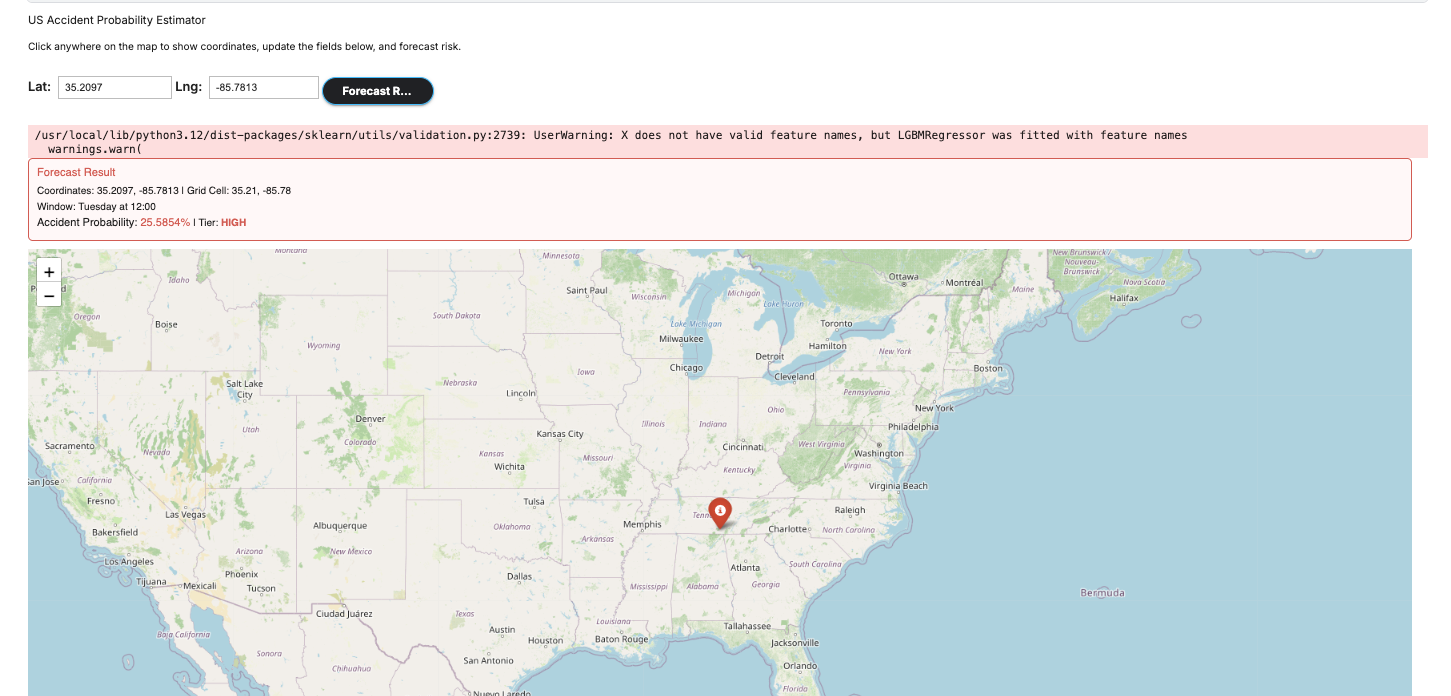